<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>ML</b></center>

<center><b><h1>Lab - 9</b></center>    
<pre>    

# Step 1: Import Libraries
This step imports all necessary libraries for data processing, visualization, and machine learning.

In [1]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Step 2: Load the Dataset
Load Given dataset -  heart.csv

In [2]:
df = pd.read_csv('heart.csv')

df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


# Step 3: Data Overview
In this step, we examine the dataset structure, summary statistics, and check for missing values.

In [3]:
df.shape

(1025, 14)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [5]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [6]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(723)

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df.duplicated().sum()


np.int64(0)

# Step 4: Univariate Analysis
Here we visualize the distribution of each feature using histograms.

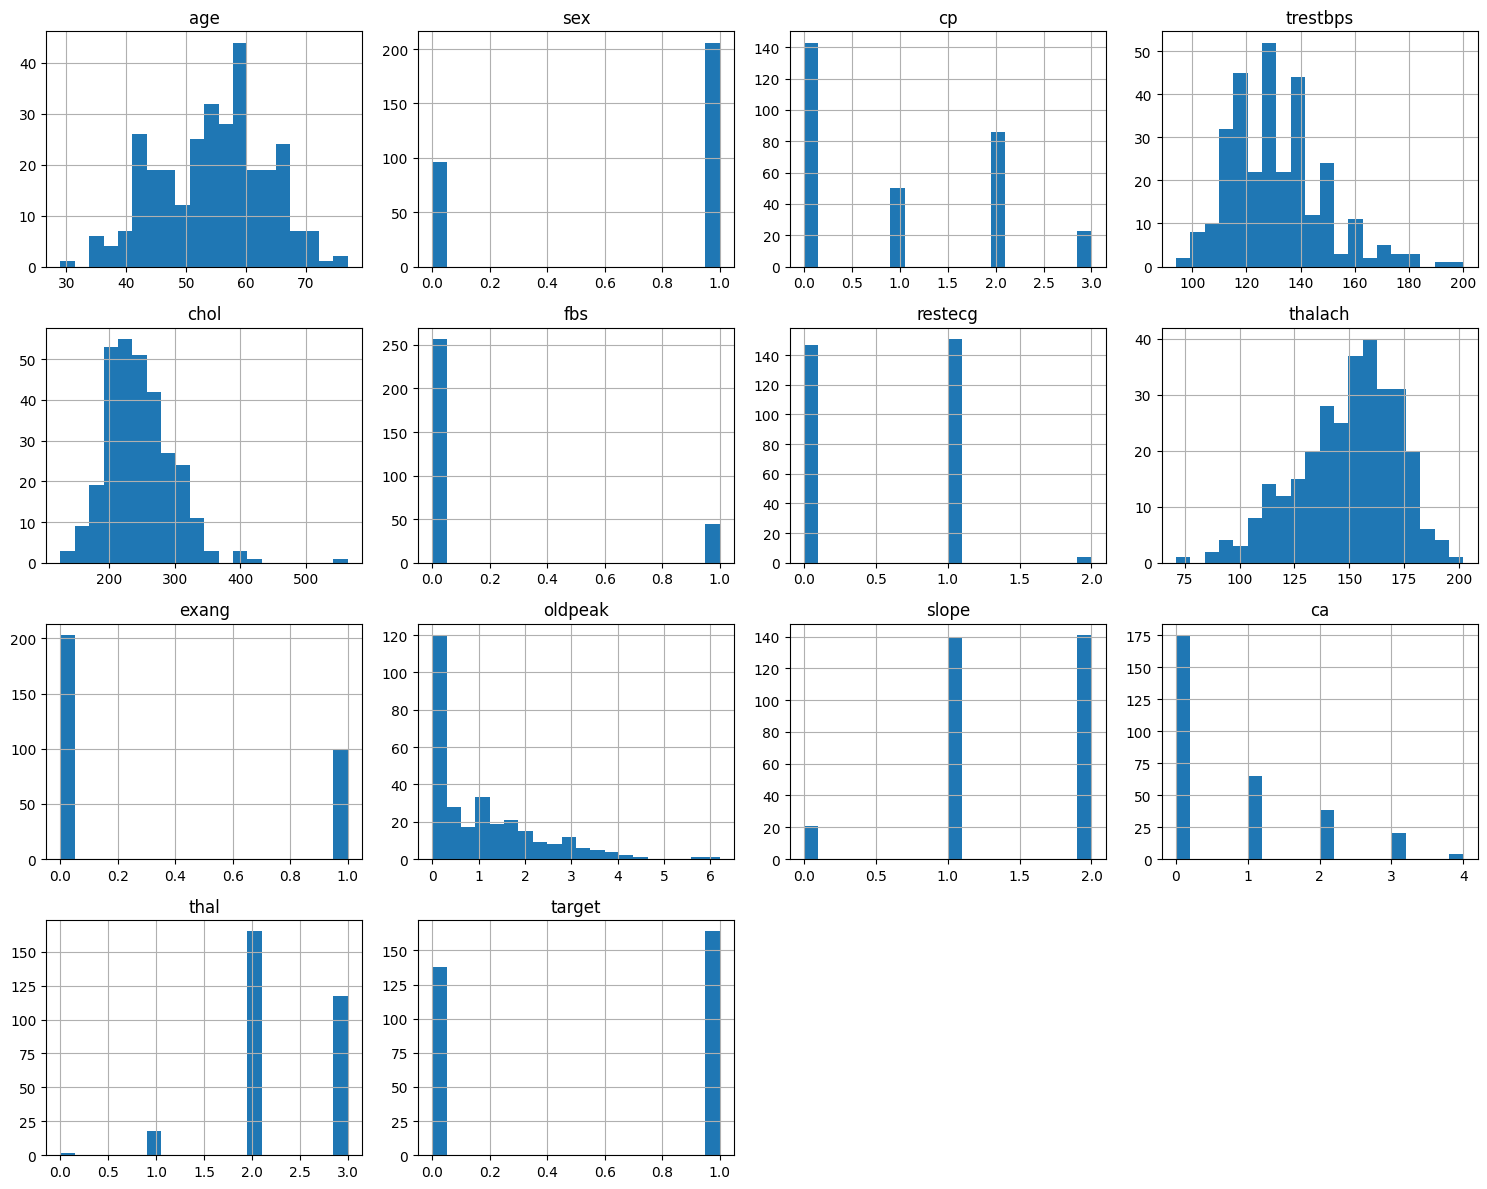

In [10]:
df.hist(figsize=(15,12), bins=20)
plt.tight_layout()
plt.show()

# Step 5: Bivariate Analysis
This step involves exploring the correlations between features using a heatmap.

In [11]:
df.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.094962,-0.063107,0.283121,0.207216,0.119492,-0.111590,-0.395235,0.093216,0.206040,-0.164124,0.302261,0.065317,-0.221476
sex,-0.094962,1.000000,-0.051740,-0.057647,-0.195571,0.046022,-0.060351,-0.046439,0.143460,0.098322,-0.032990,0.113060,0.211452,-0.283609
cp,-0.063107,-0.051740,1.000000,0.046486,-0.072682,0.096018,0.041561,0.293367,-0.392937,-0.146692,0.116854,-0.195356,-0.160370,0.432080
trestbps,0.283121,-0.057647,0.046486,1.000000,0.125256,0.178125,-0.115367,-0.048023,0.068526,0.194600,-0.122873,0.099248,0.062870,-0.146269
chol,0.207216,-0.195571,-0.072682,0.125256,1.000000,0.011428,-0.147602,-0.005308,0.064099,0.050086,0.000417,0.086878,0.096810,-0.081437
fbs,0.119492,0.046022,0.096018,0.178125,0.011428,1.000000,-0.083081,-0.007169,0.024729,0.004514,-0.058654,0.144935,-0.032752,-0.026826
restecg,-0.111590,-0.060351,0.041561,-0.115367,-0.147602,-0.083081,1.000000,0.041210,-0.068807,-0.056251,0.090402,-0.083112,-0.010473,0.134874
thalach,-0.395235,-0.046439,0.293367,-0.048023,-0.005308,-0.007169,0.041210,1.000000,-0.377411,-0.342201,0.384754,-0.228311,-0.094910,0.419955
exang,0.093216,0.143460,-0.392937,0.068526,0.064099,0.024729,-0.068807,-0.377411,1.000000,0.286766,-0.256106,0.125377,0.205826,-0.435601
oldpeak,0.206040,0.098322,-0.146692,0.194600,0.050086,0.004514,-0.056251,-0.342201,0.286766,1.000000,-0.576314,0.236560,0.209090,-0.429146


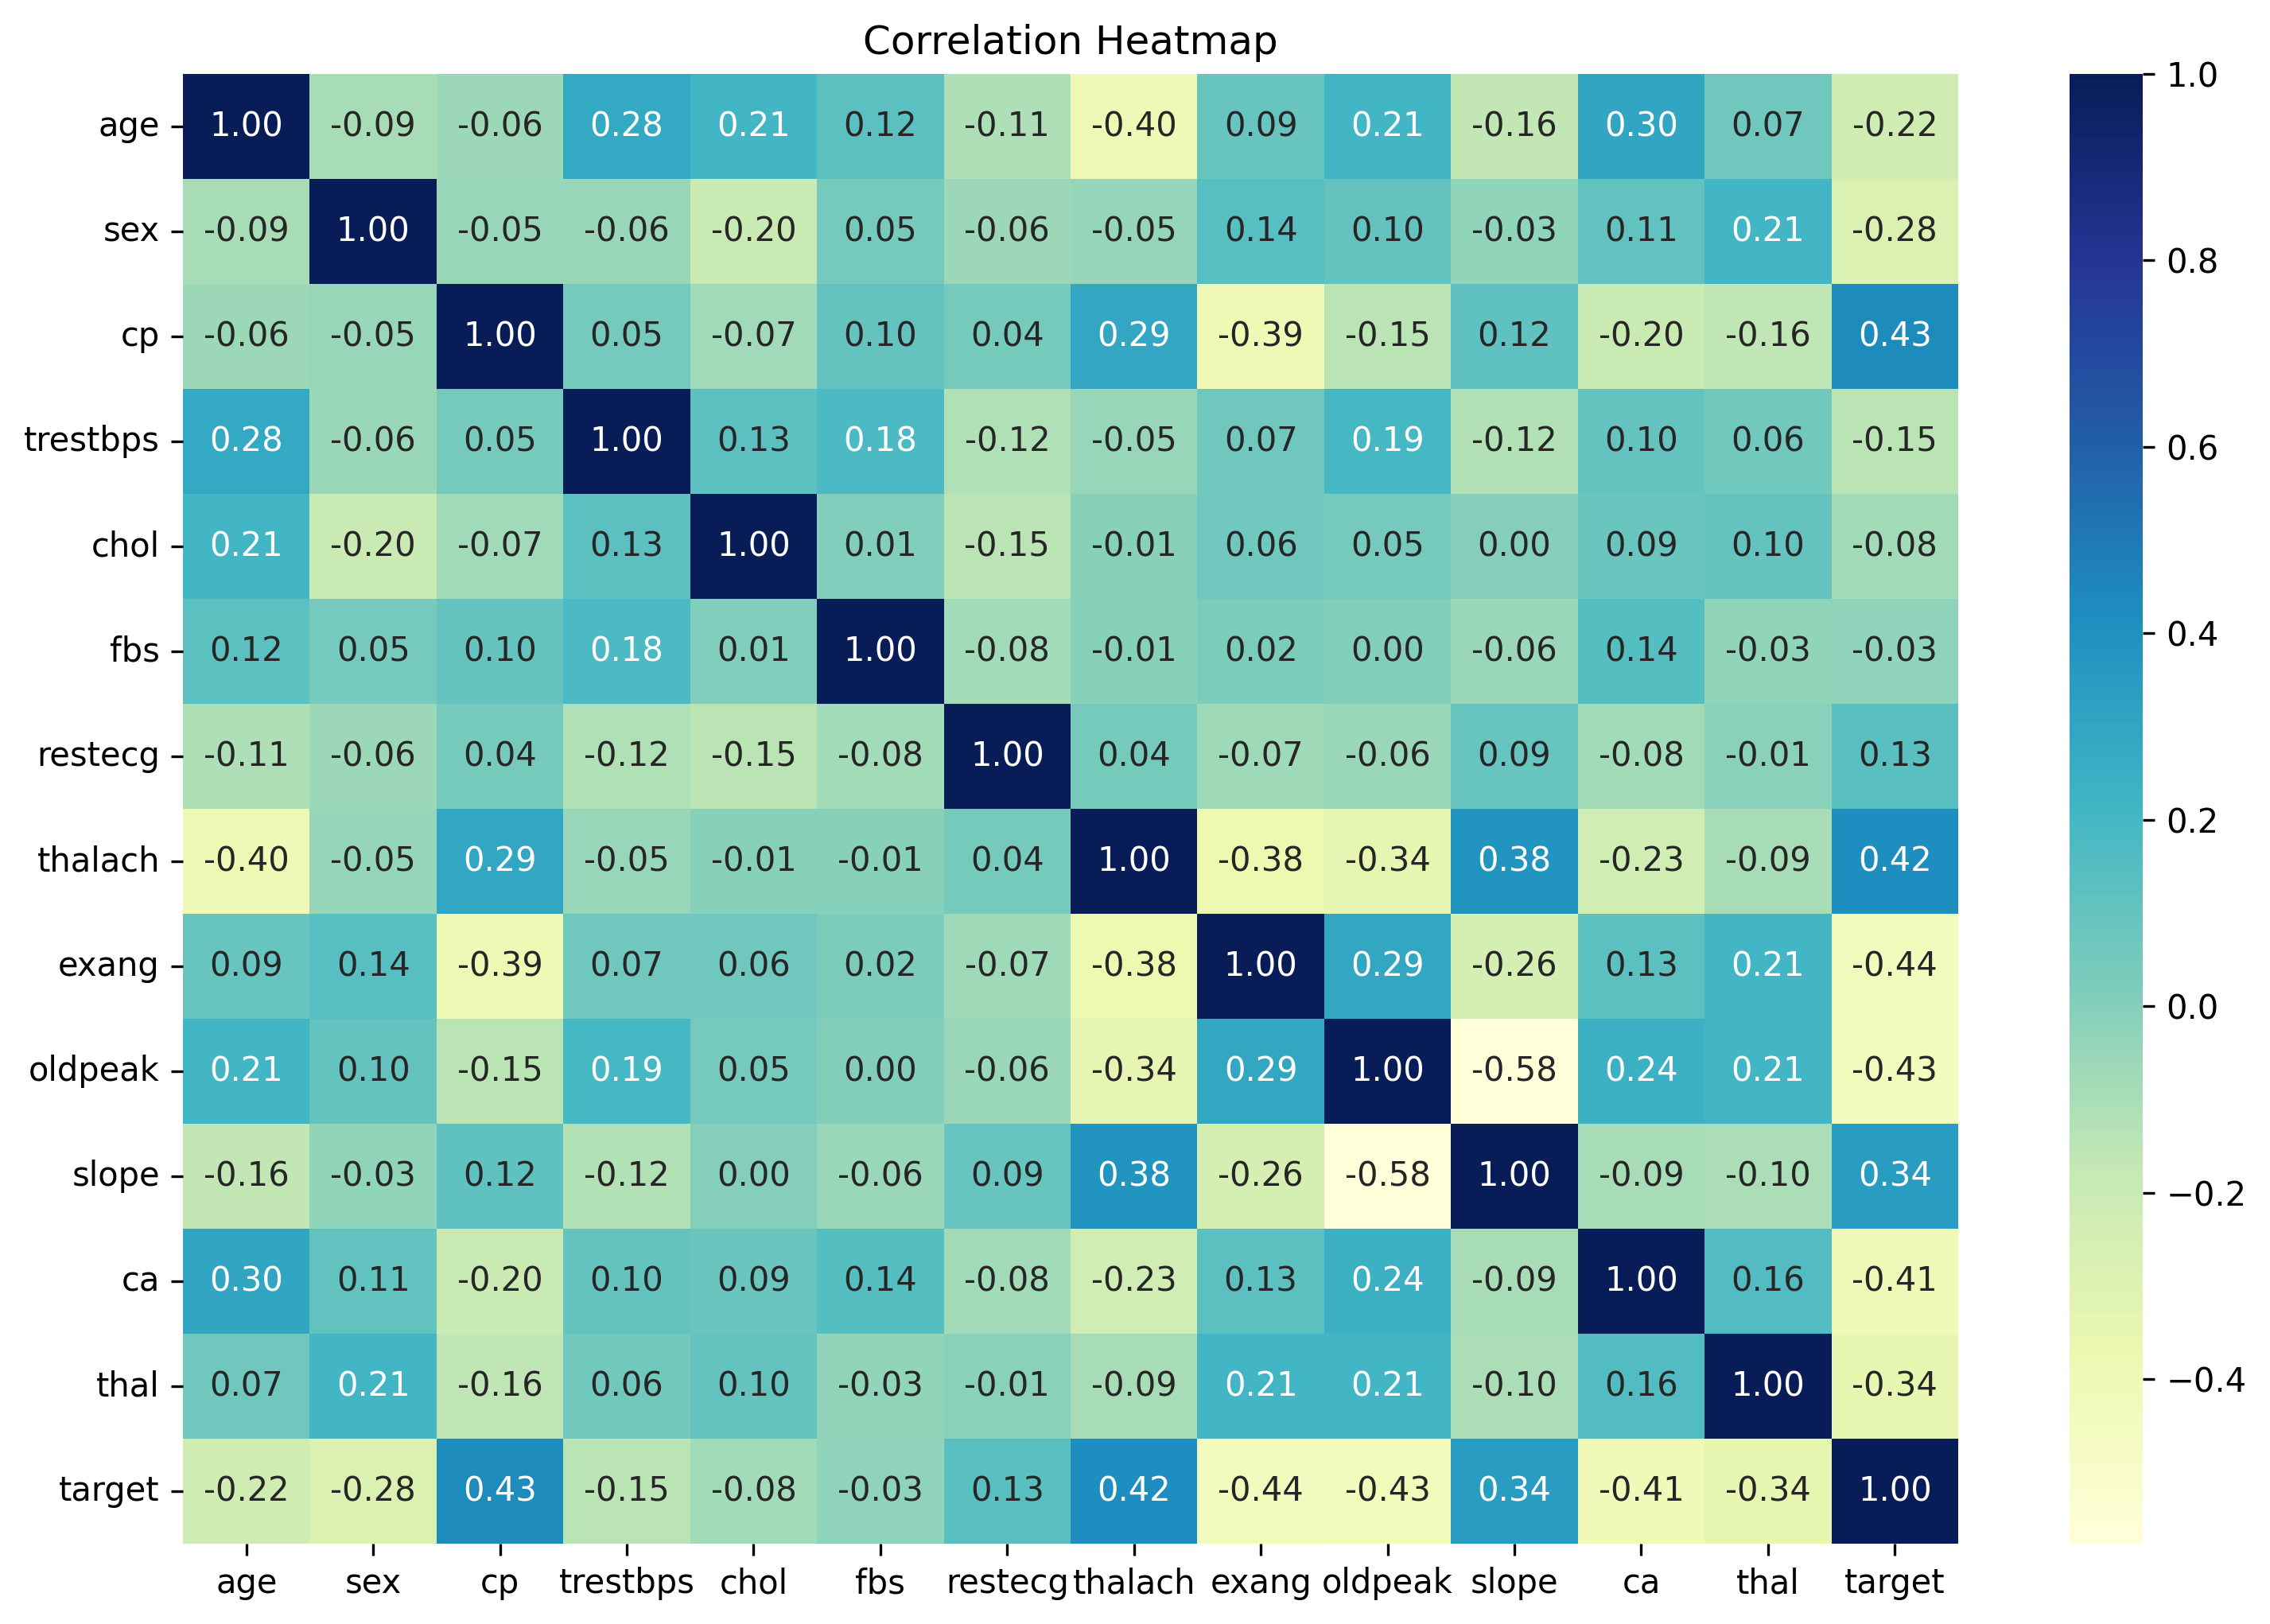

In [12]:
plt.figure(figsize=(12,8),dpi=300)

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='YlGnBu',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

# Step 6: Outlier Detection
We visualize potential outliers using boxplots.

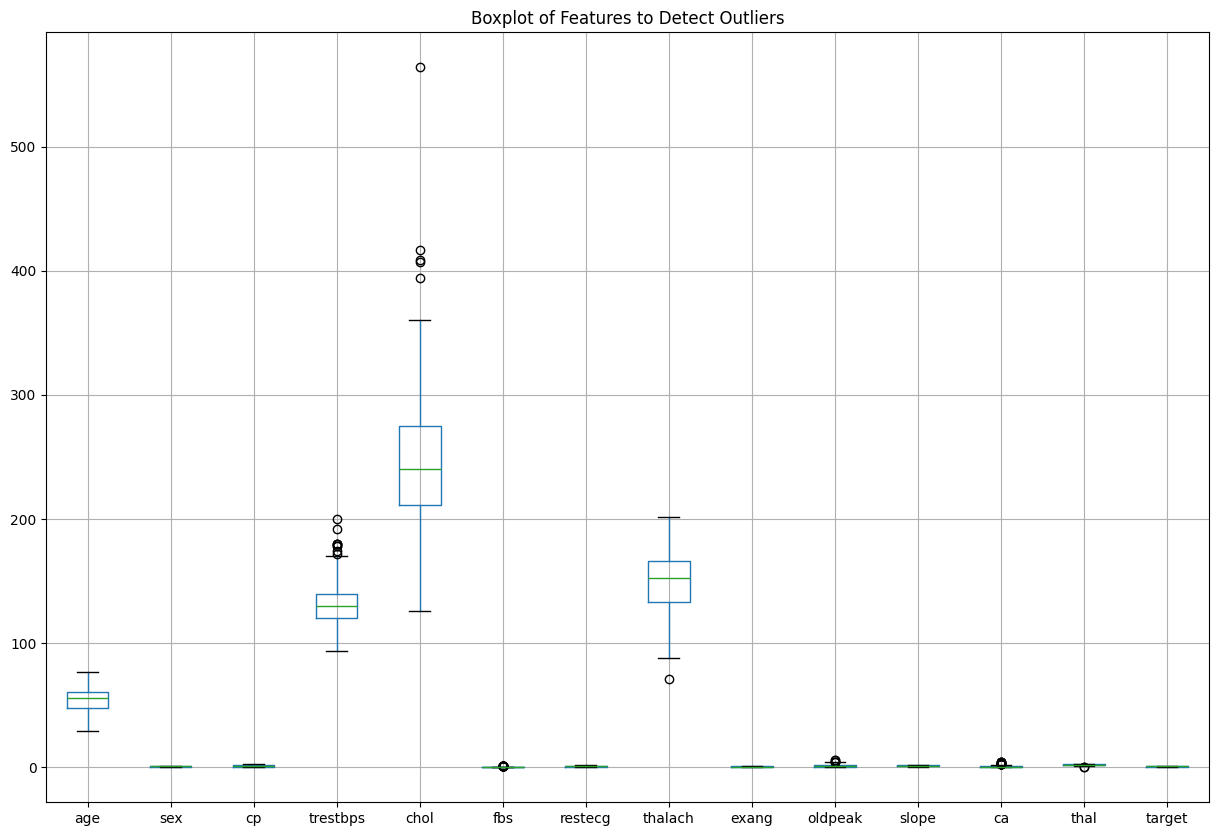

In [13]:
plt.figure(figsize=(15, 10))
df.boxplot()
plt.title('Boxplot of Features to Detect Outliers')
plt.show()

In [14]:
import warnings
warnings.filterwarnings('ignore')

# Step 7: Split Data into Training and Testing Sets
The dataset is split into training and testing sets for model evaluation.

In [15]:
X = df.drop('target', axis=1)
y = df['target']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)



# Step 8: Train KNN
train KNN with k three different  <br>
1) 1 <br>
2) root N
3) N

In [17]:
N = len(X_train)

print("Training Samples =", N)

Training Samples = 241


In [18]:
knn1 = KNeighborsClassifier(n_neighbors=1)
knn1.fit(X_train, y_train)

y_pred1 = knn1.predict(X_test)
print("Accuracy =", accuracy_score(y_test, y_pred1))

Accuracy = 0.5901639344262295


In [19]:
k_root = int(np.sqrt(N))
print("K =", k_root)

knn2 = KNeighborsClassifier(n_neighbors=k_root)
knn2.fit(X_train, y_train)

y_pred2 = knn2.predict(X_test)
print("Accuracy =", accuracy_score(y_test, y_pred2))

K = 15
Accuracy = 0.6229508196721312


In [20]:
knn3 = KNeighborsClassifier(n_neighbors=N)
knn3.fit(X_train, y_train)

y_pred3 = knn3.predict(X_test)
print("Accuracy =", accuracy_score(y_test, y_pred3))

Accuracy = 0.5409836065573771


# Now train on Z score of Input

## here we retrain all model with standardize data

# Apply StandardScaler

In [21]:
sc = StandardScaler()

X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

# K = 1

In [22]:
knn1_scaled = KNeighborsClassifier(n_neighbors=1)
knn1_scaled.fit(X_train_scaled, y_train)

y_pred1_scaled = knn1_scaled.predict(X_test_scaled)
print("Accuracy =", accuracy_score(y_test, y_pred1_scaled))

Accuracy = 0.7213114754098361


# K = √N

In [23]:
knn2_scaled = KNeighborsClassifier(n_neighbors=k_root)
knn2_scaled.fit(X_train_scaled, y_train)

y_pred2_scaled = knn2_scaled.predict(X_test_scaled)
print("Accuracy =", accuracy_score(y_test, y_pred2_scaled))

Accuracy = 0.8360655737704918


# K = N

In [24]:
knn3_scaled = KNeighborsClassifier(n_neighbors=N)
knn3_scaled.fit(X_train_scaled, y_train)

y_pred3_scaled = knn3_scaled.predict(X_test_scaled)
print("Accuracy =", accuracy_score(y_test, y_pred3_scaled))

Accuracy = 0.5409836065573771


In [25]:
results = pd.DataFrame({
    'N_neighbour' : ['1','Root N','N','1','Root N','N'],
    'Data': [
        'Original',
        'Original',
        'Original',
        'Z-Score',
        'Z-Score',
        'Z-Score'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred1),
        accuracy_score(y_test, y_pred2),
        accuracy_score(y_test, y_pred3),
        accuracy_score(y_test, y_pred1_scaled),
        accuracy_score(y_test, y_pred2_scaled),
        accuracy_score(y_test, y_pred3_scaled)
    ]
})

results

,N_neighbour,Data,Accuracy
0,1,Original,0.590164
1,Root N,Original,0.622951
2,N,Original,0.540984
3,1,Z-Score,0.721311
4,Root N,Z-Score,0.836066
5,N,Z-Score,0.540984


# confusion matrix

In [26]:
cm = confusion_matrix(y_test, y_pred3)
cm

array([[ 0, 28],
       [ 0, 33]])

In [27]:
cr = classification_report(y_test, y_pred3)
print(cr)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        28
           1       0.54      1.00      0.70        33

    accuracy                           0.54        61
   macro avg       0.27      0.50      0.35        61
weighted avg       0.29      0.54      0.38        61



# Train Decision Tree

In [28]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(X_train,y_train)
y_predict = model.predict(X_test)

In [29]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_predict)

0.7377049180327869

In [30]:
model.score(X_test,y_test)

0.7377049180327869

# Cross Validation

In [31]:
from sklearn.model_selection import KFold
k = KFold(n_splits=10)

In [32]:
for train_index, test_index in k.split(X):
    x_train, x_test = X.values[train_index], X.values[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model1 = DecisionTreeClassifier()
    model1.fit(x_train, y_train)

    print(model1.score(x_test, y_test))

0.8064516129032258
0.6774193548387096
0.8
0.6666666666666666
0.8333333333333334
0.7
0.8333333333333334
0.7666666666666667
0.7666666666666667
0.8333333333333334


In [33]:
from sklearn.model_selection import cross_val_score
cross_val_score(model,X,y,cv=k)


array([0.80645161, 0.64516129, 0.8       , 0.66666667, 0.83333333,
       0.73333333, 0.8       , 0.76666667, 0.7       , 0.8       ])

# Train Bagging Classifier
We train a Bagging Classifier with Decision Trees as the base model.

In [ ]:
from sklearn.ensemble import BaggingClassifier

bc = BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=3),
                        n_estimators=100)
bc.fit(x_train, y_train)

In [38]:
y_predict = bc.predict(x_test)
accuracy_score(y_test,y_predict)


0.8

In [44]:
# accuracy_score(y_train,bc.predict(x_train))
bc.score(x_train,y_train)


0.8676470588235294

# Train Random Forest
We train a Random Forest Classifier on the dataset.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(n_estimators=100,max_features='sqrt')
rfc.fit(x_train,y_train)

In [61]:
y_predict = rfc.predict(x_test)
accuracy_score(y_test,y_predict)

0.8333333333333334

In [62]:
rfc.score(x_train,y_train)

1.0

# Feature Importance in Random Forest
We analyze feature importance as determined by the Random Forest model.

In [ ]:
rfc.feature_importances_

np.float64(1.0)

# Train AdaBoost Classifier
We train an AdaBoost Classifier on the dataset.

In [48]:
from sklearn.ensemble import AdaBoostClassifier
adbc = AdaBoostClassifier(n_estimators=100,estimator=DecisionTreeClassifier(max_depth=1))
adbc.fit(x_train,y_train)


,estimator,DecisionTreeC...r(max_depth=1)
,n_estimators,100
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,None
,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0


In [49]:
y_predict = adbc.predict(x_test)
accuracy_score(y_test,y_predict)

0.8333333333333334

In [64]:
adbc.score(x_train,y_train)

0.8970588235294118

In [70]:
m1 = (bc.score(x_train,y_train)-bc.score(x_test,y_test))*100
m2 = (rfc.score(x_train,y_train)-rfc.score(x_test,y_test))*100
m3 = (adbc.score(x_train,y_train)-adbc.score(x_test,y_test))*100

In [71]:
print("Bagging Classifier : ", m1)
print("Random Forest Classifier : ", m2)
print("AdaBoost Classifier : ", m3)

Bagging Classifier :  6.764705882352939
Random Forest Classifier :  16.666666666666664
AdaBoost Classifier :  6.372549019607843
